In [1]:
# NEED TO RUN THIS WITHIN FUTUREFLOOD_CLEAN

In [12]:
import os
import rioxarray as rxr
import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import iris
import iris.plot as iplt
import iris.quickplot as qplt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import re
from tqdm import tqdm
from rioxarray.merge import merge_arrays

SOIL_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/soil_texture/"
CATCHMENT_DIR = "/scratch/hydro4/users/kv25483/FutureFlood/Data/CatchmentShapefiles/"

HA_NUM = 2

from run_HC_conversion import aggregate_to_5km, convert_to_netcdf, filter_closer_to_catchment

### Get hydraulic conductivity lookup

In [2]:
hydraulic_conductivity_lookup = pd.read_csv("../../Data/Soil_Info.csv")

# 1. Build a lookup dictionary from the CSV
#    adjust column name to match your actual hydraulic conductivity column
lookup = dict(zip(
    hydraulic_conductivity_lookup["USDA_soil"],
    hydraulic_conductivity_lookup["Hydraulic_conductivity"]))

### Get catchment boundary

In [3]:
catchments = gpd.read_file(CATCHMENT_DIR + "hyd_areas_GB_with_subcatchments.shp")
this_catchment = catchments[catchments['HA_NUM'] == str(HA_NUM)]
this_catchment.reset_index(inplace=True, drop=True)
this_catchment_poly = this_catchment.geometry[0]

### Get soil texture data

In [4]:
soil_file = SOIL_DIR + f"soil_30m_{HA_NUM}.tif"
soil_texture = rxr.open_rasterio(soil_file, chunks={"x": 2000, "y": 2000}).squeeze()
# Get rid of -9999 values
soil_texture = soil_texture.where(soil_texture != -9999)
# Check
# print(soil_texture.rio.resolution())
# np.unique(soil_texture.values, return_counts= True)

### Check soil texture data

In [5]:
# # Get unique classes (sorted, ignoring NaNs if needed)
# classes = np.unique(soil_texture.values)
# classes = classes[~np.isnan(classes)]

# # Create discrete colormap
# cmap = plt.get_cmap("Set1", len(classes))

# # Create boundaries between classes
# bounds = np.arange(len(classes) + 1) - 0.5
# norm = mcolors.BoundaryNorm(bounds, cmap.N)

# fig, ax = plt.subplots(figsize=(7,5))

# im = soil_texture.plot(ax=ax, cmap=cmap,norm=norm, add_colorbar=True,
#     cbar_kwargs={"ticks": np.arange(len(classes)), "label": "Soil Texture"})

# # Optional: label ticks with actual class values
# cbar = im.colorbar
# cbar.set_ticklabels(classes.astype(int))  # or keep as strings if categorical

# ax.set_title("Soil Texture (30m)")
# plt.tight_layout()
# plt.show()

### Convert soil texture data to hydraulic conducitivity values

In [6]:
# Get the raw numpy array
soil_values = soil_texture.values  # shape (2450, 2855)

# Create output array, defaulting to NaN
hk_values = np.full(soil_values.shape, np.nan)

# Map each USDA class to its hydraulic conductivity value
for usda_class, hk in lookup.items():
    hk_values[soil_values == usda_class] = hk

# Put back into an xarray DataArray, preserving spatial metadata
hk_raster = soil_texture.copy(data=hk_values)
hk_raster.name = "hydraulic_conductivity"

### Join HC values over UK and plot

In [9]:
ha_nums = catchments['HA_NUM'].unique()

# Load first cube to get the shape/metadata as template
first = iris.load(f"../../Data/HydraulicConductivity/5km_{ha_nums[0]}.nc")[0]
national_data = np.full(first.shape, np.nan, dtype=np.float32)

for ha_num in tqdm(ha_nums):
    hk_in = iris.load(f"../../Data/HydraulicConductivity/5km_{ha_num}.nc")[0]
    data = hk_in.data  # numpy array or masked array
    
    # Handle masked arrays
    if np.ma.is_masked(data):
        valid = ~data.mask
    else:
        valid = ~np.isnan(data)
    
    # Only fill where this catchment has data and national is still empty
    national_data[valid] = data[valid]

# Put back into a cube using the first cube as template
national_cube = first.copy(data=national_data)
national_cube.rename("hydraulic_conductivity")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 114/114 [00:05<00:00, 21.82it/s]


In [13]:
hk_rasters = []

for ha_num in tqdm(ha_nums):
    soil_file = SOIL_DIR + f"soil_30m_{ha_num}.tif"
    if not os.path.exists(soil_file):
        continue

    soil_texture = rxr.open_rasterio(soil_file).squeeze()  # avoid dask chunks here; merge wants computed arrays
    soil_texture = soil_texture.where(soil_texture != -9999)

    soil_values = soil_texture.values
    hk_values = np.full(soil_values.shape, np.nan, dtype=np.float32)
    for usda_class, hk in lookup.items():
        hk_values[soil_values == usda_class] = hk

    hk_raster = soil_texture.copy(data=hk_values)
    hk_raster.name = "hydraulic_conductivity"
    hk_raster.rio.write_crs(soil_texture.rio.crs, inplace=True)

    hk_rasters.append(hk_raster)
    
national_hc = merge_arrays(hk_rasters, nodata=np.nan)
national_hc.name = "hydraulic_conductivity"    

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 114/114 [00:12<00:00,  9.36it/s]


In [ ]:
# Coarsen purely for visualization — e.g. factor of 20 → ~600m effective res for the plot
# plot_data = national_hc.coarsen(x=20, y=20, boundary="trim").mean()

fig = plt.figure(figsize=(8, 10))
ax = plt.axes(projection=ccrs.epsg(27700))  # adjust EPSG if your tiles are in a different CRS

national_hc.plot(ax=ax, cmap='plasma', add_colorbar=True,
                cbar_kwargs={'label': 'Hydraulic Conductivity (m/day)'})

ax.coastlines(resolution='50m', linewidth=0.5, color='black')
ax.set_title('National Hydraulic Conductivity (m/day)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Aggregate 30m HC values to 5km grid (taking the mean)

In [17]:
GRID_5KM_FILE = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall/5km/Ens_01/bc_pr_rcp85_land-cpm_uk_5km_01_1hr_19901201-19911130.nc"

hk_5km, qa = aggregate_to_5km(GRID_5KM_FILE, hk_raster, return_qa_array = True)
# print(hk_5km.shape)       # should be (ny, nx)
# print(np.nanmin(hk_5km), np.nanmax(hk_5km))  # sanity check values
# print(np.nanmin(hk_raster), np.nanmax(hk_raster))  # sanity check values

In [ ]:
# print(hk_5km.shape)       # should be (ny, nx)
# print(np.nanmin(hk_5km), np.nanmax(hk_5km))  # sanity check values
# print(np.nanmin(hk_raster), np.nanmax(hk_raster))  # sanity check values

### Sense check
The qa contains the number of the 5km cell that each 30m cell was assigned to. Plotting this we can check whether we see blocks of cells all together all assigned to the same 5km cell. We see that here, implies things worked fine

In [ ]:
# qa = qa.where(qa != -1)

# # Get unique cell indices present in the catchment
# unique_vals = np.unique(qa.values[~np.isnan(qa.values)]).astype(int)
# n = len(unique_vals)

# cmap = plt.get_cmap("YlGn", n)

# val_to_rank = np.full(int(unique_vals.max()) + 1, np.nan)
# val_to_rank[unique_vals] = np.arange(n)

# # Handle NaNs safely before indexing
# qa_vals = qa.values.copy()
# valid_mask = ~np.isnan(qa_vals)

# qa_ranked_vals = np.full(qa_vals.shape, np.nan)  # default NaN everywhere
# qa_ranked_vals[valid_mask] = val_to_rank[qa_vals[valid_mask].astype(int)]  # only index valid pixels

# qa_ranked = xr.DataArray(qa_ranked_vals,coords=qa.coords,dims=qa.dims)

# fig, ax = plt.subplots(figsize=(5, 5))
# qa_ranked.plot(ax=ax, cmap=cmap, add_colorbar=False)
# ax.set_title("QA: 5km cell assignment (each colour = one unique cell)")
# plt.show()

### Convert to a netCDF and save to file

In [18]:
hk_out = convert_to_netcdf(GRID_5KM_FILE, hk_5km)
hk_out.to_netcdf(f"../../Data/HydraulicConductivity/5km_{HA_NUM}.nc")

### Read back in and check

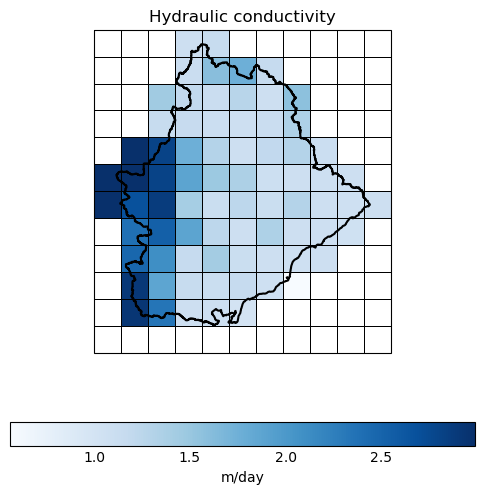

In [19]:
hk_in = iris.load(f"../../Data/HydraulicConductivity/5km_{HA_NUM}.nc")[0]
test =filter_closer_to_catchment(hk_in, this_catchment_poly, True, this_catchment)